In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score

In [2]:
cell_line = "DU4475"

In [3]:
true = pd.read_csv("/Users/adr/Box/BioFuzzNet/BFN/Model/Mini_subnetwork/DU4475/valid_data.csv", index_col=0).reset_index(drop=True)
pred = pd.read_csv("/Users/adr/Box/BioFuzzNet/BFN/Model/Mini_subnetwork/DU4475/valid_output_states.csv", index_col=0).reset_index(drop=True)

In [4]:
pred_nodes = set(pred.columns).intersection(set(true.columns))
root_nodes = set(["AKT_S473", "SMAD23", "GSK3B", "AKT_T308", "SRC", "MKK4", "AMPK", "ERK12"])
pred_nodes = list(pred_nodes.difference(root_nodes))
pred_nodes

['MAPKAPK2', 'MKK36', 'p90RSK', 'p53', 'cleavedCas', 'CREB', 'p38', 'RB', 'H3']

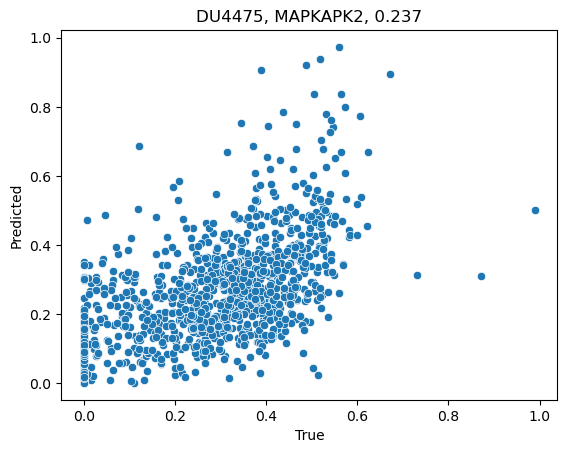

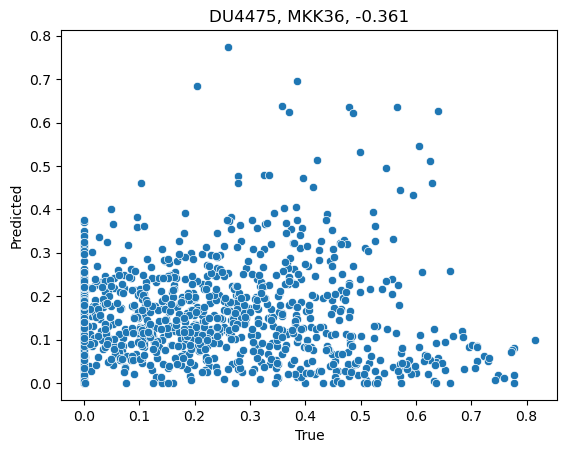

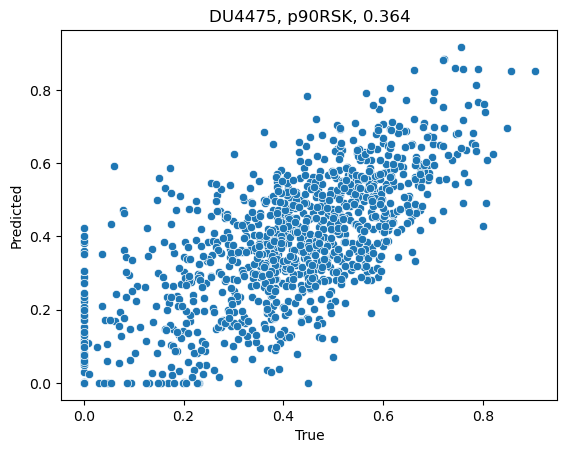

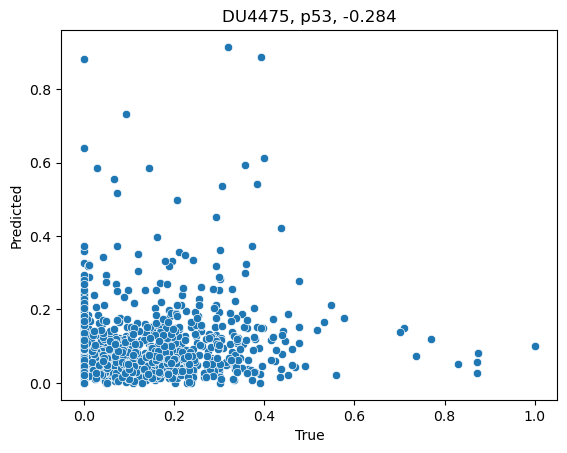

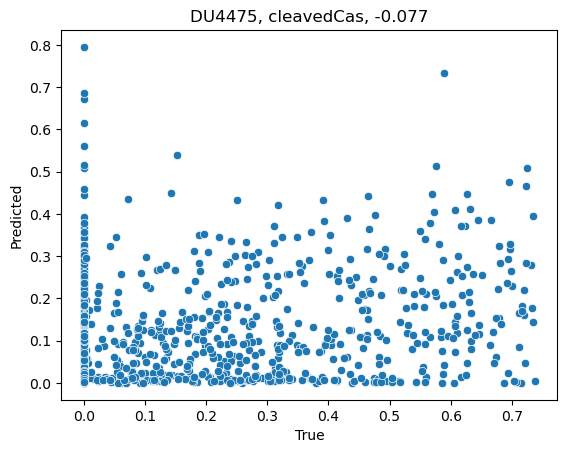

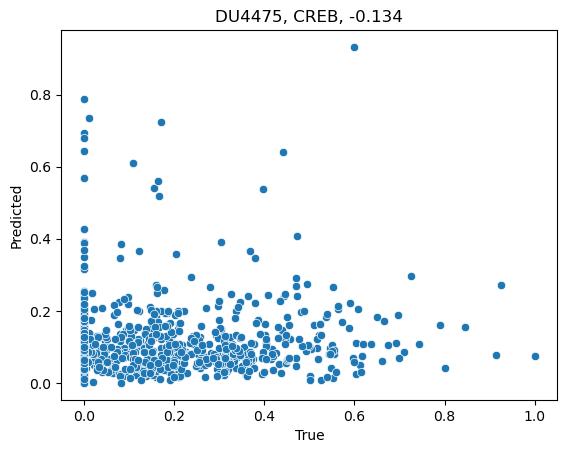

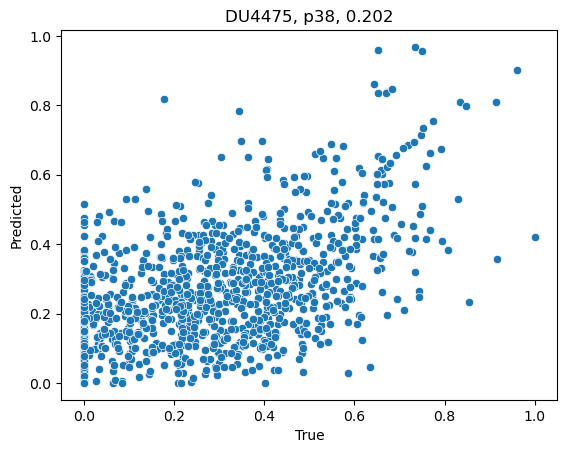

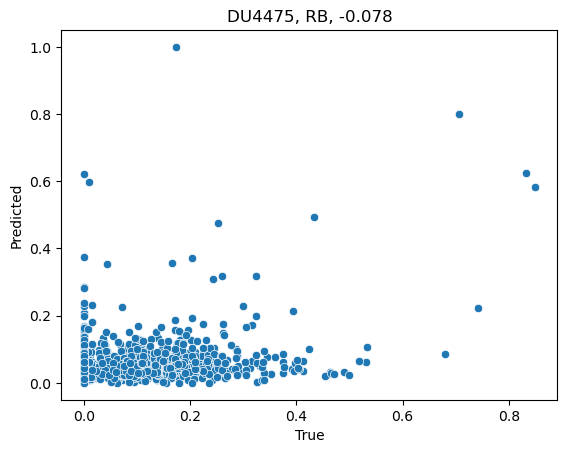

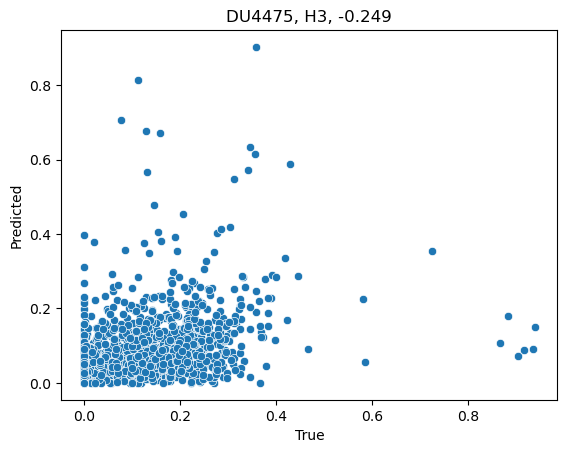

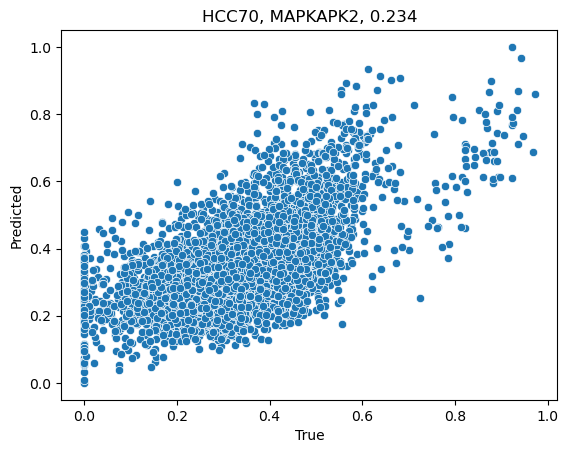

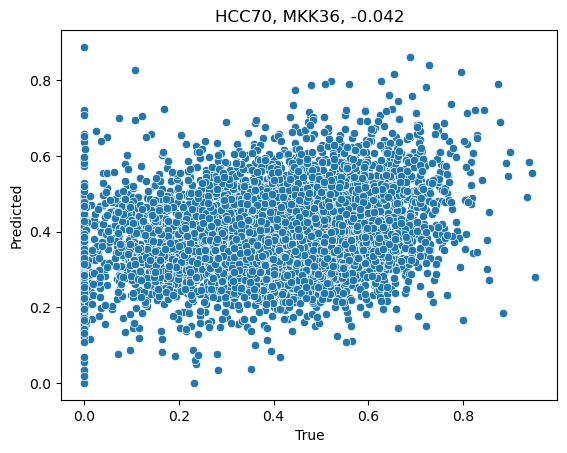

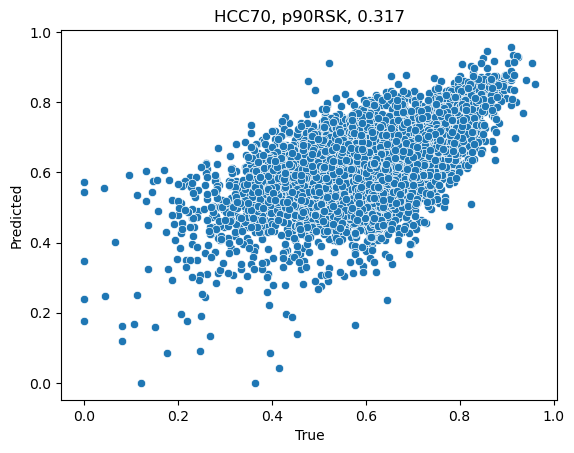

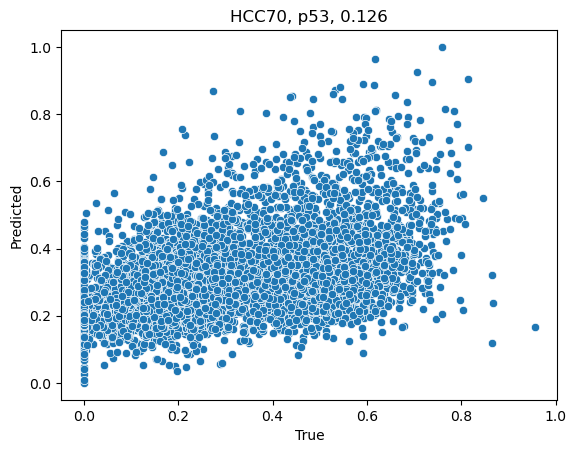

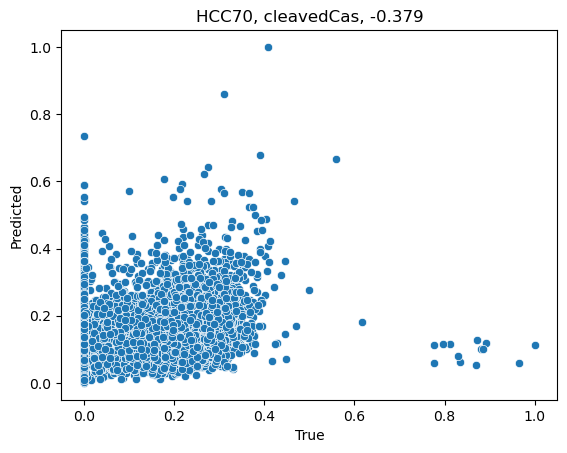

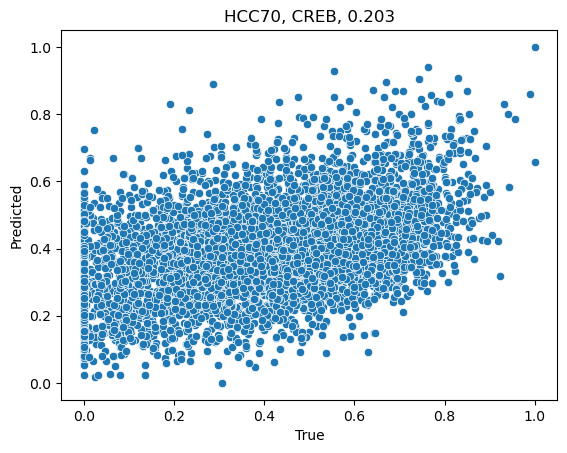

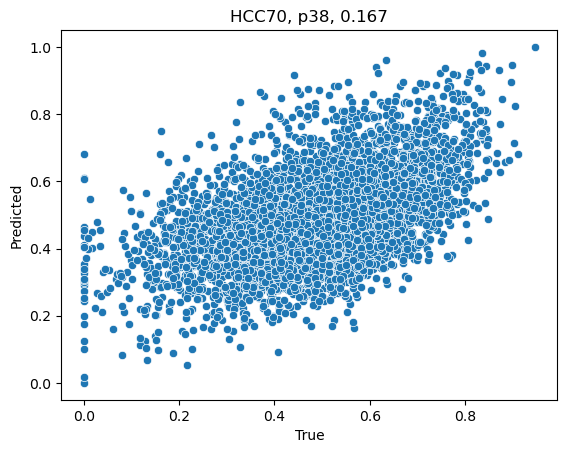

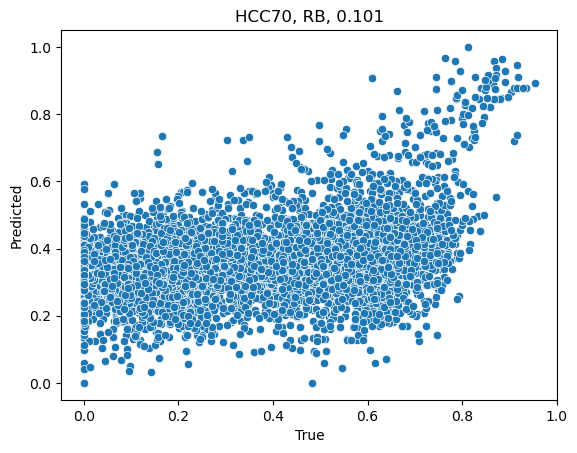

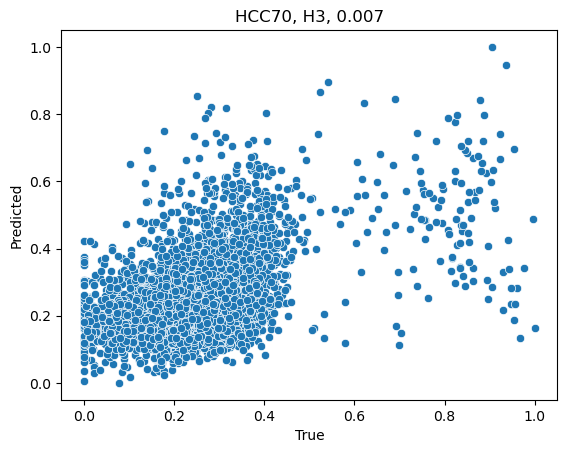

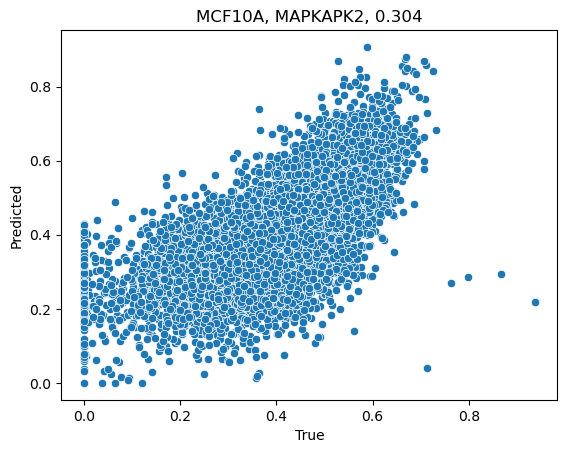

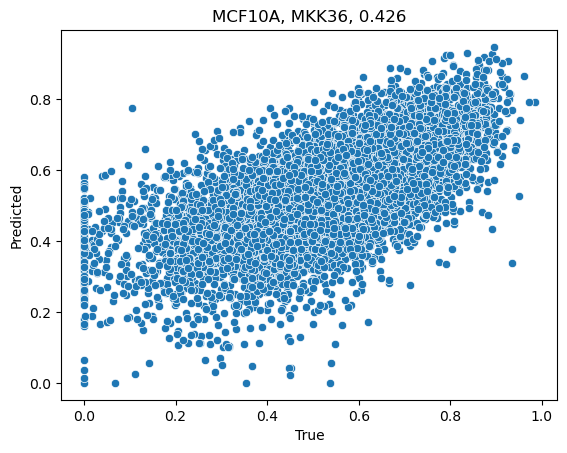

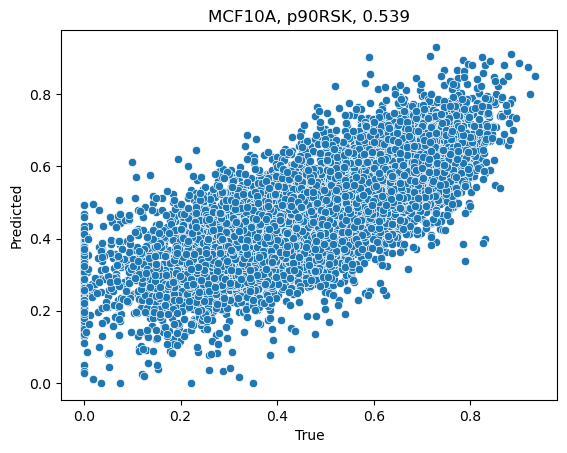

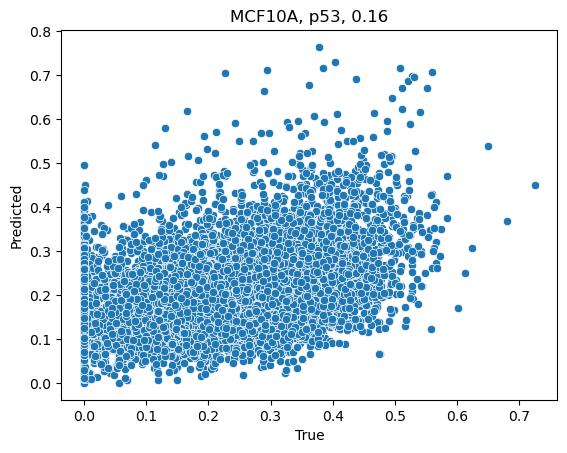

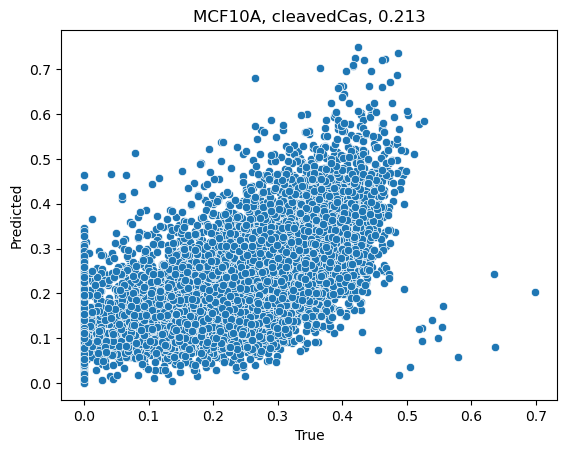

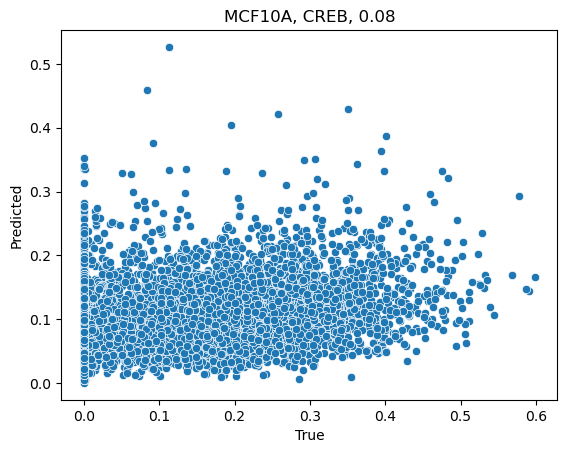

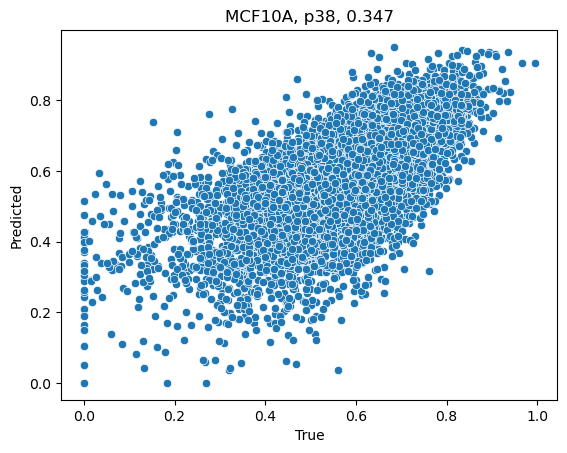

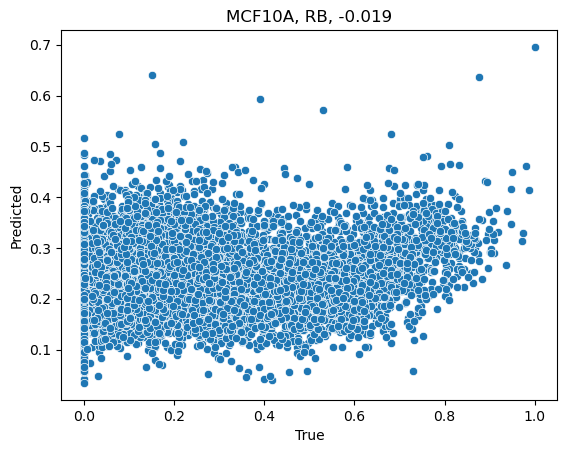

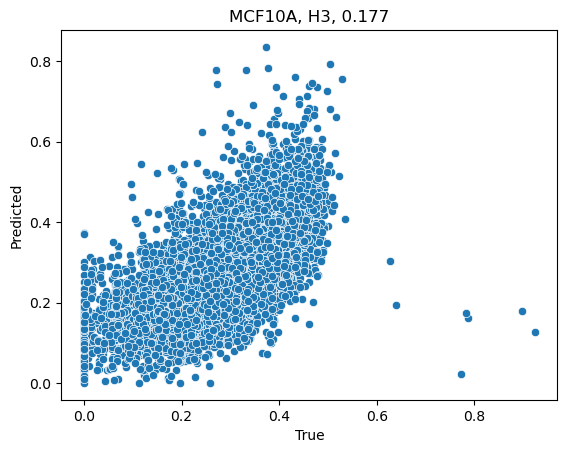

In [5]:
r2_scores = []
cell_lines = []
nodes = []
models = []
for cell_line in ["DU4475", "HCC70", "MCF10A"]:
    true = pd.read_csv(f"/Users/adr/Box/BioFuzzNet/BFN/Model/Mini_subnetwork/{cell_line}/valid_data.csv", index_col=0).reset_index(drop=True)
    pred = pd.read_csv(f"/Users/adr/Box/BioFuzzNet/BFN/Model/Mini_subnetwork/{cell_line}/valid_output_states.csv", index_col=0).reset_index(drop=True)
    lm_pred = pd.read_csv(f"/Users/adr/Box/BioFuzzNet/BFN/Model/Mini_subnetwork/{cell_line}/LM_{cell_line}_EGF_predictions.csv", index_col=0).reset_index(drop=True)
    
    for node in pred_nodes:
        r2 = r2_score(true[node], pred[node])
        r2_scores.append(r2)
        cell_lines.append(cell_line)
        nodes.append(node)
        models.append("BFN")
        
        lm_r2 = r2_score(true[node], lm_pred[node])
        r2_scores.append(lm_r2)
        cell_lines.append(cell_line)
        nodes.append(node)
        models.append("LM")
        
        sns.scatterplot(x=true[node], y=pred[node])
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title(f"{cell_line}, {node}, {round(r2, 3)}")
        plt.show()

In [6]:
results = pd.DataFrame({"cell line": cell_lines, "node": nodes, "r2": r2_scores, "model": models})
results

,cell line,node,r2,model
0,DU4475,MAPKAPK2,0.236581,BFN
1,DU4475,MAPKAPK2,0.461599,LM
2,DU4475,MKK36,-0.360710,BFN
3,DU4475,MKK36,0.155293,LM
4,DU4475,p90RSK,0.364407,BFN
5,DU4475,p90RSK,0.591890,LM
6,DU4475,p53,-0.283706,BFN
7,DU4475,p53,0.110604,LM
8,DU4475,cleavedCas,-0.077409,BFN
9,DU4475,cleavedCas,0.302142,LM


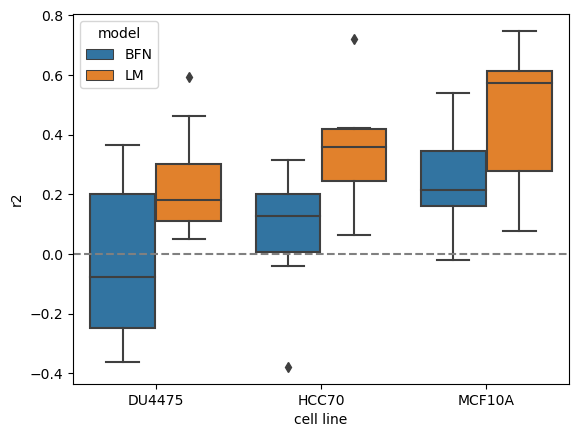

In [7]:
sns.boxplot(data=results, x="cell line", y="r2", hue="model")
plt.axhline(y=0, color="grey", linestyle="--")

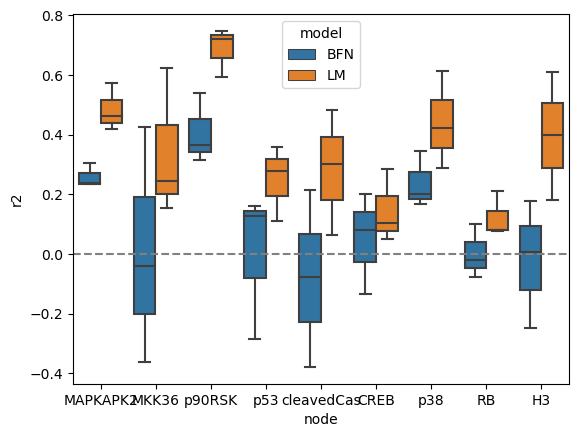

In [8]:
sns.boxplot(data=results, x="node", y="r2", hue="model")
plt.axhline(y=0, color="grey", linestyle="--")

In [9]:
results.groupby("cell line").mean(numeric_only=True)

,r2
cell line,
DU4475,0.102217
HCC70,0.214503
MCF10A,0.351977


- Check OOD prediction slightly bigger network...
- Presentation MRM

# OOD prediction not possible here --> no inhibitors in network

In [10]:
set(pred.columns).intersection(set(true.columns))

{'AKT_S473',
 'AKT_T308',
 'AMPK',
 'CREB',
 'ERK12',
 'GSK3B',
 'H3',
 'MAPKAPK2',
 'MKK36',
 'MKK4',
 'RB',
 'SMAD23',
 'SRC',
 'cleavedCas',
 'p38',
 'p53',
 'p90RSK'}